# Análisis Exploratorio de Datos (EDA) - McDonald's Reviews

En este cuaderno realizaremos un **Análisis Exploratorio de Datos (EDA)** ordenado sobre las reseñas de clientes. El objetivo es comprender mejor la distribución de los datos, identificar patrones relevantes y analizar la relación entre las diferentes variables del conjunto limpio antes de cualquier modelado.

--- 

### 1. Importación de Librerías y Carga de Datos
Iniciamos importando las librerías fundamentales para el análisis numérico, manipulación de datos y visualización pertinente.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os

In [ ]:
df = pd.read_csv("../data/McDonalds_Clean.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28516 entries, 0 to 28515
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   store_address           28516 non-null  object 
 1   latitude                28516 non-null  float64
 2   longitude               28516 non-null  float64
 3   rating_count            28516 non-null  int64  
 4   review                  28516 non-null  object 
 5   rating                  28516 non-null  int64  
 6   review_time_since_days  28516 non-null  int64  
dtypes: float64(2), int64(3), object(2)
memory usage: 1.5+ MB


In [19]:
df.describe()

,latitude,longitude,rating_count,rating
count,28516.000000,28516.000000,28516.000000,28516.000000
mean,34.118005,-91.365223,2784.740672,2.994740
std,5.387497,16.785572,2652.488580,1.633629
min,25.790295,-121.995421,263.000000,1.000000
25%,28.655350,-98.634580,1460.000000,1.000000
50%,33.931261,-81.513738,2052.000000,3.000000
75%,40.727401,-77.044235,3243.000000,5.000000
max,44.981410,-73.459820,19682.000000,5.000000


In [18]:
df.head()

,store_address,latitude,longitude,rating_count,review_time,review,rating
0,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,1240,3 months ago,Why does it look like someone spit on my food?...,1
1,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,1240,5 days ago,It'd McDonalds. It is what it is as far as the...,4
2,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,1240,5 days ago,Made a mobile order got to the speaker and che...,1
3,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,1240,a month ago,My mc. Crispy chicken sandwich was customer s...,5
4,"13749 US-183 Hwy, Austin, TX 78750, United States",30.460718,-97.792874,1240,2 months ago,"I repeat my order 3 times in the drive thru, a...",1


In [17]:
print(f"La cantidad de los nulos: \n {df.isnull().sum()}")

La cantidad de los nulos: 
 store_address    0
latitude         0
longitude        0
rating_count     0
review_time      0
review           0
rating           0
dtype: int64


<Axes: xlabel='rating', ylabel='count'>

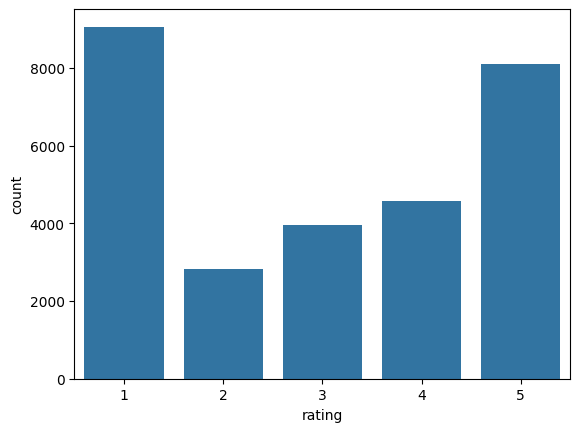

In [22]:
sns.countplot(x="rating", data=df)

### Distribución de Calificaciones (Ratings)

El primer gráfico ilustra cómo se distribuyen las calificaciones otorgadas por los clientes:
- **Eje X**: Calificación otorgada (de 1 a 5 estrellas).
- **Eje Y**: Frecuencia o cantidad de reseñas con dicha calificación.

**📌 Observaciones Clave:**
* **Tendencia a los Extremos (Polarización):** Se observa una clara concentración de apreciaciones en los valores extremos. La calificación de 1 estrella es significativamente la más frecuente, seguida por la calificación máxima de 5 estrellas. 
* **Ausencia de Términos Medios:** Las calificaciones moderadas o neutrales (2, 3 y 4 estrellas) presentan una frecuencia drásticamente menor. Esto sugiere que los clientes están mayormente motivados a dejar una reseña cuando han tenido una experiencia altamente insatisfactoria o sumamente positiva.

<Axes: xlabel='review_length', ylabel='Count'>

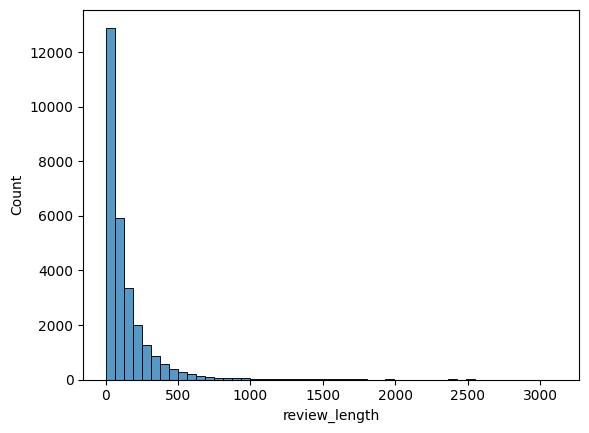

In [42]:
df["review_length"] = df["review"].str.len()
sns.histplot(df["review_length"], bins=50)

### Distribución de la Longitud de las Reseñas

A continuación, analizamos cuántos caracteres suelen plasmar los clientes al momento de redactar sus opiniones.
- **Eje X**: Número de caracteres en el texto de la reseña.
- **Eje Y**: Frecuencia (Count) de reseñas con dicha longitud.

**📌 Observaciones Clave:**
* **Distribución Sesgada a la Derecha:** La gran masa de los textos se concentra prolíficamente en el extremo izquierdo del gráfico, correspondiendo a reseñas cortas y directas (menores a 200 caracteres).
* **Formato Conciso:** Las opiniones excepcionalmente largas son muy atípicas y poco frecuentes. Esto indica que el usuario común prefiere expresarse de una manera al punto, sin extenderse con elaboradas descripciones o explicaciones.

<Axes: xlabel='rating', ylabel='review_length'>

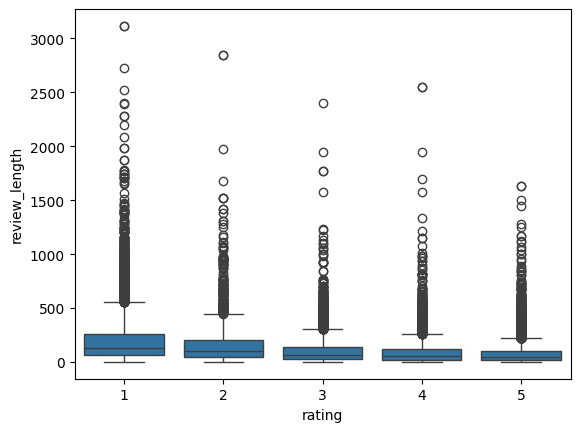

In [43]:
sns.boxplot(x="rating", y="review_length", data=df)

### Relación entre Longitud de la Reseña y Calificación (Rating)

Al relacionar las dos variables anteriores mediante un diagrama de caja (Boxplot), podemos visualizar claramente cómo la calificación de un cliente incide en su nivel de detalle expresado en la reseña.
- **Eje X**: Calificación otorgada por el usuario (Rating).
- **Eje Y**: Longitud de la reseña en cantidad de caracteres.

**📌 Observaciones Clave:**
* **Más Detalle en la Insatisfacción:** Existe una tendencia donde las calificaciones bajas (1 y 2 estrellas) albergan reseñas significativamente más largas. Las personas altamente insatisfechas usualmente sienten la urgencia de describir las razones precisas de su reclamo e inconvenientes.
* **Aprobación Breve:** A la inversa, al premiar el servicio (4 o 5 estrellas), los textos demuestran ser mucho más compactos. Una experiencia satisfactoria no parece requerir del cliente mucho más que frases rápidas (ej. "Excelente", "Muy bueno").
* **Valores Atípicos (Outliers):** Aún con esta tendencia visible, pueden apreciarse clientes en todas las categorías que extienden sus relatos a grandes longitudes (los puntos situados mucho más arriba de los bigotes principales).

<Axes: xlabel='review_time_since_days', ylabel='review_length'>

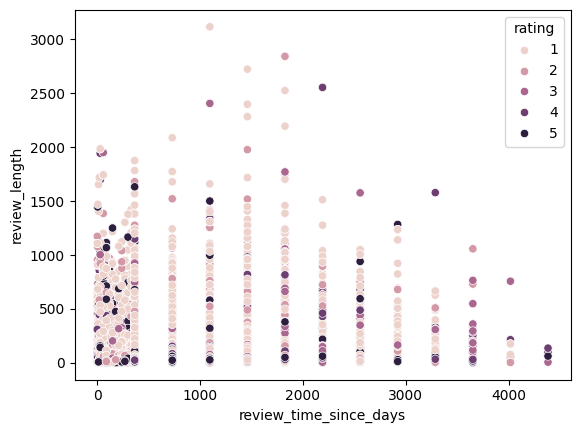

In [44]:
sns.scatterplot(
    x="review_time_since_days",
    y="review_length",
    hue="rating",
    data=df
)

### Impacto del Tiempo y Calificación sobre la Longitud de Reseña

Finalmente, exploramos un análisis multivariable cruzando la temporalidad de la publicación con la longitud y su respectivo rating o calificación.
- **Eje X**: Tiempo transcurrido (en días) desde la publicación de la reseña.
- **Eje Y**: Longitud de la reseña en la plataforma.
- **Color (Hue)**: Calificación del rating en gradiente (colores más oscuros denotan una puntuación muy alta, mientras que los más claros representan quejas o baja puntuación).

**📌 Observaciones Clave:**
* **Volumen Fuerte de Reseñas Recientes:** El peso principal de las reseñas se concentra hacia los costados de corto lazo, demostrando que la intensa mayoría de las valoraciones en la base de datos se publicaron en un horizonte de 0 a 1000 días aproximadamente.
* **Correlación Temporal Ligera:** La longitud de la reseña no demuestra tener un patrón condicionado o claro con el paso histórico del tiempo; se mantiene relativamente estable la actitud de escritura a través del tiempo.
* **Concentración Clásica:** El diagrama reitera visualmente cómo en aquellas longitudes más extensamente altas, predominan considerablemente los esquemas marcados por una tonalidad más pálida correspondiente a 1 o 2 estrellas.

---

## EDA Extendido — Features para el Modelo Random Forest

Análisis exploratorio sobre el dataset de features enriquecido (`McDonalds_Features.csv`), con variables derivadas de ingeniería de características y análisis de sentimiento NLP.

**El modelo Random Forest predice `rating_label`** (3 clases):

| Clase | Criterio |
|---|---|
| `bad` | rating < 3 (1 ó 2 estrellas) — 41.7 % |
| `neutral` | rating 3 ó 4 — 29.9 % |
| `good` | rating > 4 (5 estrellas) — 28.5 % |


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

PALETTE = {'bad': '#e74c3c', 'neutral': '#f39c12', 'good': '#2ecc71'}
LABEL_ORDER = ['bad', 'neutral', 'good']
COLORS_ORDER = [PALETTE[l] for l in LABEL_ORDER]

df = pd.read_csv('../data/processed/McDonalds_Features.csv')
print(f'Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas')
df.head(3)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Distribución del Target: rating_label', fontsize=14, fontweight='bold')

counts = df['rating_label'].value_counts().reindex(LABEL_ORDER)
bars = axes[0].bar(LABEL_ORDER, counts.values, color=COLORS_ORDER, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 80,
                 f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Conteo por categoría')
axes[0].set_xlabel('Categoría')
axes[0].set_ylabel('Número de reseñas')
axes[0].yaxis.grid(True, alpha=0.4)

pcts = counts.values / counts.sum() * 100
wedges, texts, autotexts = axes[1].pie(
    pcts, labels=LABEL_ORDER, autopct='%1.1f%%',
    colors=COLORS_ORDER, startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2})
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')
axes[1].set_title('Proporción (%)')

plt.tight_layout()
plt.show()


### Distribución del Target: `rating_label`

La columna `rating_label` clasifica cada reseña en tres categorías de satisfacción:

- **`bad`** : rating < 3 (1 ó 2 estrellas)
- **`neutral`** : rating 3 ó 4
- **`good`** : rating > 4 (5 estrellas)

**📌 Observaciones Clave:**
* **Desbalance de clases:** `bad` concentra el 41.7 % de las reseñas (neutral 29.9 %, good 28.5 %). Los clientes insatisfechos son los más motivados a dejar reseñas, patrón coherente con el análisis previo de ratings.
* **Implicación para el modelo:** El desbalance se compensa con `class_weight='balanced'` en el Random Forest para evitar sesgo hacia la clase mayoritaria.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Rating numérico (1-5) por Categoría', fontsize=14, fontweight='bold')

sns.boxplot(data=df, x='rating_label', y='rating', order=LABEL_ORDER,
            palette=PALETTE, ax=axes[0], linewidth=1.2)
axes[0].set_title('Box-plot: Rating vs Categoría')
axes[0].set_xlabel('Categoría')
axes[0].set_ylabel('Rating (1-5)')
axes[0].yaxis.grid(True, alpha=0.4)

for label, color in PALETTE.items():
    subset = df[df['rating_label'] == label]['rating']
    axes[1].hist(subset, bins=5, alpha=0.72, label=label, color=color, edgecolor='white')
axes[1].set_title('Histograma de Rating por Categoría')
axes[1].set_xlabel('Rating (1-5)')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()
axes[1].yaxis.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()


### Rating Numérico (1-5) por Categoría

Box-plot e histograma del rating numérico original dentro de cada categoría de `rating_label`.

**📌 Observaciones Clave:**
* **Separación clara:** Por construcción, cada categoría agrupa rangos distintos de ratings (1-2 → bad, 3-4 → neutral, 5 → good), lo que valida la coherencia del etiquetado.
* **`good` tiene varianza cero:** Todos los valores son exactamente 5, mientras que `bad` y `neutral` presentan variación interna.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Análisis de Sentimiento por Categoría', fontsize=14, fontweight='bold')

metrics = [
    ('sentiment_compound',     'VADER Compound (-1 a +1)'),
    ('sentiment_polarity',     'TextBlob Polarity (-1 a +1)'),
    ('sentiment_subjectivity', 'TextBlob Subjectivity (0 a 1)'),
]
for ax, (col, title) in zip(axes, metrics):
    sns.violinplot(data=df, x='rating_label', y=col, order=LABEL_ORDER,
                   palette=PALETTE, ax=ax, inner='quartile', linewidth=1)
    ax.set_title(title)
    ax.set_xlabel('Categoría')
    ax.set_ylabel(col)
    ax.yaxis.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()


### Análisis de Sentimiento por Categoría

Tres métricas de sentimiento calculadas a partir del texto de la reseña:

- **VADER Compound** (`sentiment_compound`): Score de -1 (muy negativo) a +1 (muy positivo).
- **TextBlob Polarity** (`sentiment_polarity`): Polaridad de -1 a +1.
- **TextBlob Subjectivity** (`sentiment_subjectivity`): Subjetividad de 0 (objetivo) a 1 (subjetivo).

**📌 Observaciones Clave:**
* **El sentimiento refleja el rating:** Las reseñas `good` tienen distribuciones desplazadas hacia valores positivos, y las `bad` hacia negativos. Confirma que el texto es un predictor relevante de la satisfacción.
* **Solapamiento en `neutral`:** Mayor ambigüedad textual en ratings intermedios.
* **Subjetividad uniforme:** No varía significativamente entre categorías; no es un discriminador clave por sí solo.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Longitud de Reseña por Categoría', fontsize=14, fontweight='bold')

sns.boxplot(data=df, x='rating_label', y='review_length', order=LABEL_ORDER,
            palette=PALETTE, ax=axes[0], showfliers=False, linewidth=1.2)
axes[0].set_title('Longitud en caracteres')
axes[0].set_xlabel('Categoría')
axes[0].set_ylabel('Caracteres')
axes[0].yaxis.grid(True, alpha=0.4)

sns.boxplot(data=df, x='rating_label', y='review_word_count', order=LABEL_ORDER,
            palette=PALETTE, ax=axes[1], showfliers=False, linewidth=1.2)
axes[1].set_title('Conteo de palabras')
axes[1].set_xlabel('Categoría')
axes[1].set_ylabel('Palabras')
axes[1].yaxis.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()


### Longitud de Reseña por Categoría

- **`review_length`**: Número de caracteres en la reseña.
- **`review_word_count`**: Número de palabras en la reseña.

**📌 Observaciones Clave:**
* **Las reseñas negativas son más largas:** `bad` presenta medianas y rangos intercuartílicos mayores. Los clientes insatisfechos elaboran más sus quejas.
* **Las reseñas positivas son más concisas:** `good` agrupa reseñas más cortas ('Excelente', 'Muy recomendado').
* **`neutral` ocupa la posición intermedia:** Consistente con su naturaleza ambigua.


In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(13, 9))
ax.set_title('Mapa de Correlación — Features Numéricas', fontsize=14, fontweight='bold', pad=14)
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(145, 10, as_cmap=True)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap=cmap,
            center=0, linewidths=0.5, annot_kws={'size': 8}, ax=ax)
plt.tight_layout()
plt.show()


### Mapa de Correlación entre Features Numéricas

Correlaciones de Pearson entre todas las variables numéricas del dataset de features.

**📌 Observaciones Clave:**
* **Alta correlación entre métricas de sentimiento:** `sentiment_compound` y `sentiment_polarity` miden polaridad del texto de forma similar.
* **`review_length` y `review_word_count` altamente correlacionados:** Miden lo mismo con distinta unidad.
* **`rating_normalized` correlaciona con sentimiento:** El texto tiende a ser coherente con la puntuación del cliente.
* **`rating_vs_sentiment_gap` detecta inconsistencias:** Reseñas con tono diferente al rating numérico.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Tiempo desde la Reseña por Categoría', fontsize=14, fontweight='bold')

sns.boxplot(data=df, x='rating_label', y='review_time_since_days', order=LABEL_ORDER,
            palette=PALETTE, ax=axes[0], showfliers=False, linewidth=1.2)
axes[0].set_title('Días desde la reseña (box-plot)')
axes[0].set_xlabel('Categoría')
axes[0].set_ylabel('Días')
axes[0].yaxis.grid(True, alpha=0.4)

for label, color in PALETTE.items():
    pct = df[df['rating_label'] == label]['is_recent_review'].mean() * 100
    bar = axes[1].bar(label, pct, color=color, edgecolor='white')
    axes[1].text(list(PALETTE.keys()).index(label), pct + 0.4,
                 f'{pct:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].set_title('% reseñas recientes (≤ 90 días)')
axes[1].set_xlabel('Categoría')
axes[1].set_ylabel('% Recientes')
axes[1].yaxis.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()


### Tiempo desde la Reseña por Categoría

- **`review_time_since_days`**: Días transcurridos desde la reseña.
- **`is_recent_review`**: Flag booleano (1 si la reseña tiene ≤ 90 días).

**📌 Observaciones Clave:**
* **Reseñas recientes ligeramente más positivas:** El porcentaje de `is_recent_review=1` es marginalmente mayor en `good`.
* **Alta varianza:** La distribución de días es amplia en todas las categorías; el tiempo no es un predictor fuerte por sí solo.


In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.set_title('Número de Ratings del Local por Categoría', fontsize=13, fontweight='bold')
sns.boxplot(data=df, x='rating_label', y='rating_count', order=LABEL_ORDER,
            palette=PALETTE, ax=ax, showfliers=False, linewidth=1.2)
ax.set_xlabel('Categoría')
ax.set_ylabel('Cantidad de ratings del local')
ax.yaxis.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


### Popularidad del Local (`rating_count`) por Categoría

`rating_count` indica el número total de ratings recibidos por el local. Es un proxy de la popularidad o tráfico del establecimiento.

**📌 Observaciones Clave:**
* **Distribución similar entre categorías:** La popularidad del local no es un factor determinante para distinguir entre reseñas buenas, neutrales o malas.
* **Outliers con alto `rating_count`:** En todas las categorías existen locales de altísimo tráfico.


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_title('Gap: Rating Normalizado – Sentimiento Compuesto', fontsize=13, fontweight='bold')
for label, color in PALETTE.items():
    subset = df[df['rating_label'] == label]['rating_vs_sentiment_gap']
    ax.hist(subset, bins=40, alpha=0.7, label=label, color=color, edgecolor='white')
ax.axvline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.7)
ax.set_xlabel('Gap (rating_norm − sentiment_compound)')
ax.set_ylabel('Frecuencia')
ax.legend()
ax.yaxis.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


### Gap entre Rating Normalizado y Sentimiento

`rating_vs_sentiment_gap = rating_normalized − sentiment_compound` mide la **inconsistencia** entre la puntuación numérica y el tono del texto.

- **Gap positivo:** El cliente puso un rating alto pero escribió con tono negativo.
- **Gap negativo:** El cliente puso un rating bajo pero escribió con tono positivo.
- **Gap ≈ 0:** El texto es coherente con el rating.

**📌 Observaciones Clave:**
* **`good` tiene gap desplazado a la derecha:** El sentimiento textual no siempre alcanza el máximo positivo en reseñas de 5 estrellas.
* **`bad` tiene gap desplazado a la izquierda:** El texto negativo suele superar en negatividad al rating numérico.
* **Detecta sarcasmo y ambigüedad textual**, siendo una feature valiosa para el modelo de ML.


In [ ]:
top_cities = df['city'].value_counts().head(15).reset_index()
top_cities.columns = ['city', 'count']
cluster_counts = df['location_cluster'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Distribución Geográfica', fontsize=14, fontweight='bold')

palette_cities = sns.color_palette('Blues_d', 15)
axes[0].barh(top_cities['city'][::-1], top_cities['count'][::-1],
             color=palette_cities[::-1], edgecolor='white')
axes[0].set_title('Top 15 ciudades por reseñas')
axes[0].set_xlabel('Número de reseñas')
axes[0].set_ylabel('Ciudad')
axes[0].xaxis.grid(True, alpha=0.4)

palette_clusters = sns.color_palette('viridis', len(cluster_counts))
axes[1].bar(cluster_counts.index.astype(str), cluster_counts.values,
            color=palette_clusters, edgecolor='white')
axes[1].set_title('Reseñas por Clúster de Ubicación (KMeans)')
axes[1].set_xlabel('Clúster')
axes[1].set_ylabel('Número de reseñas')
axes[1].yaxis.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()


### Distribución Geográfica

Distribución de reseñas por ciudad y por clúster de ubicación (KMeans sobre latitud y longitud).

**📌 Observaciones Clave:**
* **Concentración en grandes ciudades:** Houston, Chicago, San Antonio, etc. reflejan mayor número de locales McDonald's y mayor actividad en Google Maps.
* **Los clústeres capturan agrupaciones regionales:** Pueden reflejar variaciones culturales o demográficas en la percepción del servicio.
* **Importancia moderada en el modelo RF:** `city_enc` y `location_cluster` influyen en la satisfacción del cliente.
